# M4.Ex2: Penguins Classification (PyCaret)

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M6/exercises/ex2_pycaret_classification.ipynb)

## Exercise

Your task is to follow the steps outlined here, and apply them on the **Palmer Penguins Dataset** below:

- [**🚀 Classification**](https://pycaret.gitbook.io/docs/get-started/quickstart#classification)
    - Setup
    - Compare Models
    - Analyze Model
    - Predictions
    - Save the model

## Palmer Penguins Dataset

The goal of palmer penguins is to provide a great dataset for data exploration & visualization, as an alternative to iris.

The data contains 344 penguins. There are 3 different species of penguins in this dataset, collected from 3 islands in the Palmer Archipelago, Antarctica.

- Features: `4` numerical, `2` categorical
- Target: `species` (Categorical / 3 classes)
- Size: `344` samples
- Source: [Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/)

### Load the data

In [3]:
import seaborn as sns

penguins = sns.load_dataset('penguins')
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


## Experiments

1. **First experiment**:
    - X = Flipper Length (numerical) & Bill Length (numerical)
    - y = Species (categorical)
2. **Second experiment**:
    - X = Weights (numerical) & Species (categorical)
    - y = Sex (categroical)
3. **Third experiment**:
    - X = `island`, `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`
    - y = Sex and Species (multi-label classification)

In [1]:
pip install pycaret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 11.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 10.7 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of pmdarima to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 163.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 

In [1]:
from pycaret.classification import *

## First experiment:

In [4]:
data1 = penguins[['flipper_length_mm', 'bill_length_mm', 'species']]

setup(data=data1, target='species', session_id=123)
best1 = compare_models()

,Description,Value
0,Session id,123
1,Target,species
2,Target type,Multiclass
3,Target mapping,"Adelie: 0, Chinstrap: 1, Gentoo: 2"
4,Original data shape,"(344, 3)"
5,Transformed data shape,"(344, 3)"
6,Transformed train set shape,"(240, 3)"
7,Transformed test set shape,"(104, 3)"
8,Numeric features,2
9,Rows with missing values,0.6%


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9542,0.9867,0.9542,0.9608,0.9550,0.9287,0.9309,0.0150
xgboost,Extreme Gradient Boosting,0.9542,0.9876,0.9542,0.9607,0.9549,0.9286,0.9310,0.0800
knn,K Neighbors Classifier,0.9500,0.9767,0.9500,0.9544,0.9482,0.9207,0.9237,0.1710
gbc,Gradient Boosting Classifier,0.9458,0.0000,0.9458,0.9550,0.9465,0.9159,0.9194,0.0180
lr,Logistic Regression,0.9417,0.0000,0.9417,0.9475,0.9406,0.9080,0.9113,0.2260
ridge,Ridge Classifier,0.9417,0.0000,0.9417,0.9472,0.9397,0.9071,0.9106,0.0030
dt,Decision Tree Classifier,0.9417,0.9574,0.9417,0.9482,0.9424,0.9090,0.9115,0.1640
lda,Linear Discriminant Analysis,0.9417,0.0000,0.9417,0.9472,0.9397,0.9071,0.9106,0.0030
nb,Naive Bayes,0.9375,0.9879,0.9375,0.9419,0.9366,0.9016,0.9044,0.1710
qda,Quadratic Discriminant Analysis,0.9375,0.0000,0.9375,0.9419,0.9354,0.9010,0.9047,0.0030


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [6]:
print(best1)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=123, verbose=0,
                       warm_start=False)


### Analyze Model

In [7]:
evaluate_model(best1)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

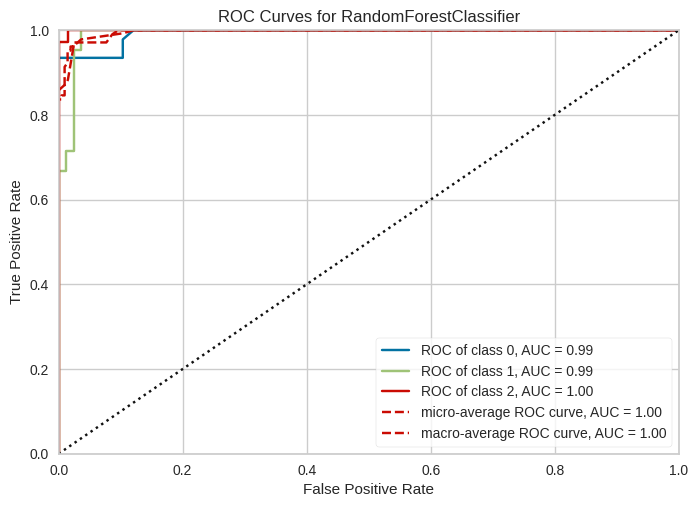

In [8]:
plot_model(best1, plot = 'auc')

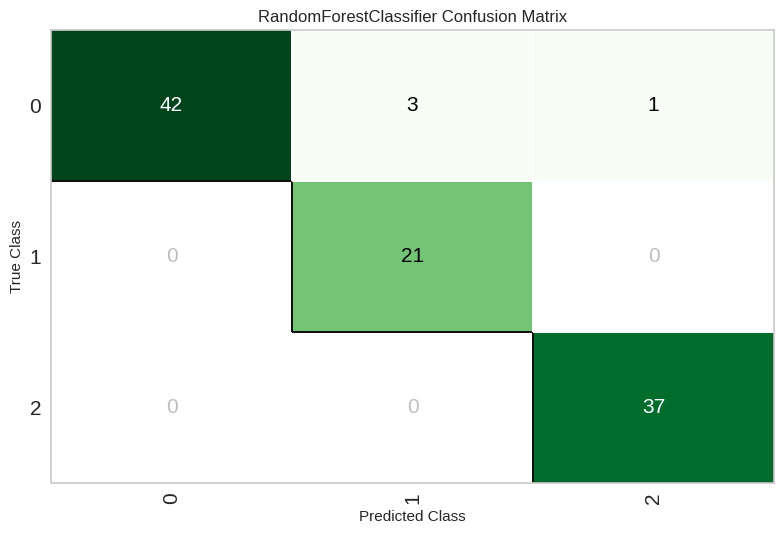

In [9]:
plot_model(best1, plot = 'confusion_matrix')

### Predictions

In [10]:
predict_model(best1)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.9615,0.9952,0.9615,0.9654,0.9617,0.9403,0.9422


,flipper_length_mm,bill_length_mm,species,prediction_label,prediction_score
166,190.0,45.900002,Chinstrap,Chinstrap,0.79
96,190.0,38.099998,Adelie,Adelie,1.00
157,198.0,45.200001,Chinstrap,Chinstrap,0.68
259,208.0,48.700001,Gentoo,Gentoo,0.90
210,202.0,50.200001,Chinstrap,Chinstrap,0.95
...,...,...,...,...,...
278,208.0,43.200001,Gentoo,Gentoo,0.92
32,188.0,39.500000,Adelie,Adelie,0.99
185,203.0,51.000000,Chinstrap,Chinstrap,0.93
149,193.0,37.799999,Adelie,Adelie,1.00


In [11]:
predictions = predict_model(best1, data=penguins)
predictions.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.9884,0.9992,0.9884,0.9888,0.9884,0.9818,0.9820


,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,species,prediction_label,prediction_score
0,Torgersen,39.099998,18.700001,181.0,3750.0,Male,Adelie,Adelie,1.00
1,Torgersen,39.500000,17.400000,186.0,3800.0,Female,Adelie,Adelie,1.00
2,Torgersen,40.299999,18.000000,195.0,3250.0,Female,Adelie,Adelie,1.00
3,Torgersen,NaN,NaN,NaN,NaN,NaN,Adelie,Gentoo,0.68
4,Torgersen,36.700001,19.299999,193.0,3450.0,Female,Adelie,Adelie,1.00


In [13]:
predictions = predict_model(best1, data=penguins, raw_score=True)
predictions.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.9884,0.9992,0.9884,0.9888,0.9884,0.9818,0.9820


,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,species,prediction_label,prediction_score_Adelie,prediction_score_Chinstrap,prediction_score_Gentoo
0,Torgersen,39.099998,18.700001,181.0,3750.0,Male,Adelie,Adelie,1.00,0.00,0.00
1,Torgersen,39.500000,17.400000,186.0,3800.0,Female,Adelie,Adelie,1.00,0.00,0.00
2,Torgersen,40.299999,18.000000,195.0,3250.0,Female,Adelie,Adelie,1.00,0.00,0.00
3,Torgersen,NaN,NaN,NaN,NaN,NaN,Adelie,Gentoo,0.14,0.18,0.68
4,Torgersen,36.700001,19.299999,193.0,3450.0,Female,Adelie,Adelie,1.00,0.00,0.00


### Save the model



In [14]:
save_model(best1, 'my_best_pipeline')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['flipper_length_mm',
                                              'bill_length_mm'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               miss...
                  RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                         class_weight=None, criterion='gini',

====================================================================

## Second experiment:

In [16]:
data2 = penguins[['body_mass_g', 'species', 'sex']].dropna(subset=['sex'])

setup(data=data2, target='sex', session_id=123)
best2 = compare_models()

,Description,Value
0,Session id,123
1,Target,sex
2,Target type,Binary
3,Target mapping,"Female: 0, Male: 1"
4,Original data shape,"(333, 3)"
5,Transformed data shape,"(333, 5)"
6,Transformed train set shape,"(233, 5)"
7,Transformed test set shape,"(100, 5)"
8,Numeric features,1
9,Categorical features,1


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.8627,0.9139,0.8627,0.8683,0.8617,0.7249,0.7305,0.0090
ridge,Ridge Classifier,0.8591,0.9459,0.8591,0.8623,0.8586,0.7176,0.7209,0.0040
lda,Linear Discriminant Analysis,0.8551,0.9423,0.8551,0.8594,0.8544,0.7097,0.7141,0.0050
lr,Logistic Regression,0.8543,0.9344,0.8543,0.8587,0.8539,0.7083,0.7127,0.2220
et,Extra Trees Classifier,0.8373,0.8657,0.8373,0.8489,0.8354,0.6737,0.6852,0.0150
dt,Decision Tree Classifier,0.8371,0.8546,0.8371,0.8467,0.8352,0.6737,0.6832,0.1720
lightgbm,Light Gradient Boosting Machine,0.8330,0.9314,0.8330,0.8433,0.8306,0.6647,0.6752,20.4820
xgboost,Extreme Gradient Boosting,0.8328,0.9219,0.8328,0.8398,0.8313,0.6647,0.6719,0.0780
rf,Random Forest Classifier,0.8288,0.9043,0.8288,0.8357,0.8273,0.6569,0.6639,0.0160
gbc,Gradient Boosting Classifier,0.8201,0.9197,0.8201,0.8269,0.8184,0.6392,0.6461,0.0100


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

### Analyze Model

In [18]:
evaluate_model(best2)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

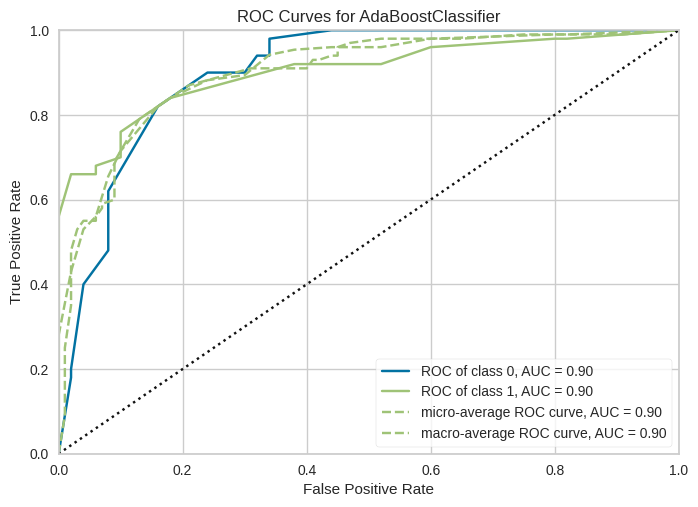

In [19]:
plot_model(best2, plot = 'auc')

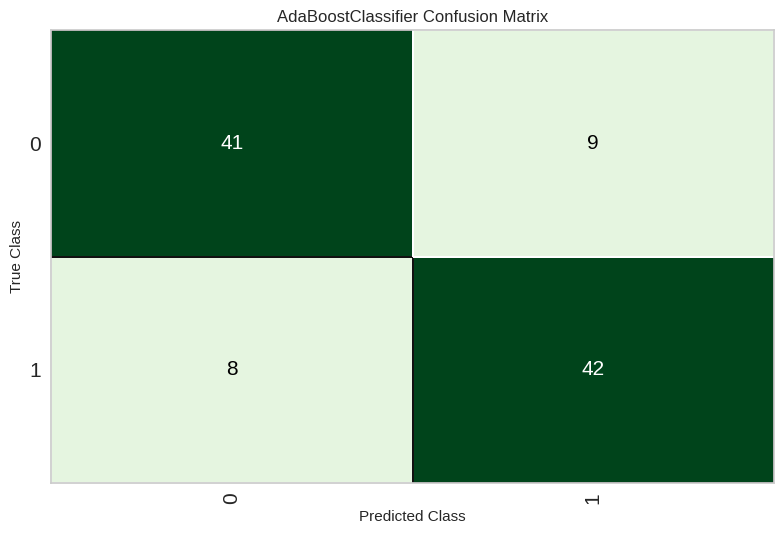

In [20]:
plot_model(best2, plot = 'confusion_matrix')

### Predictions

In [21]:
predict_model(best2)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.8300,0.9020,0.8300,0.8301,0.8300,0.6600,0.6601


,body_mass_g,species,sex,prediction_label,prediction_score
211,3525.0,Chinstrap,Female,Female,0.5048
219,3775.0,Chinstrap,Female,Male,0.5070
116,2900.0,Adelie,Female,Female,0.6786
242,4400.0,Gentoo,Female,Female,0.5268
99,4100.0,Adelie,Male,Male,0.5199
...,...,...,...,...,...
38,3300.0,Adelie,Female,Female,0.5063
202,3325.0,Chinstrap,Female,Female,0.5190
4,3450.0,Adelie,Female,Female,0.5102
250,5250.0,Gentoo,Male,Male,0.6768


In [23]:
predictions = predict_model(best2, data=penguins.dropna(subset=['sex']))
predictions.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.8679,0.9431,0.8679,0.8679,0.8679,0.7357,0.7357


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,prediction_label,prediction_score
0,Adelie,Torgersen,39.099998,18.700001,181.0,3750.0,Male,Male,0.5070
1,Adelie,Torgersen,39.500000,17.400000,186.0,3800.0,Female,Male,0.5028
2,Adelie,Torgersen,40.299999,18.000000,195.0,3250.0,Female,Female,0.6786
4,Adelie,Torgersen,36.700001,19.299999,193.0,3450.0,Female,Female,0.5102
5,Adelie,Torgersen,39.299999,20.600000,190.0,3650.0,Male,Female,0.5048


In [25]:
predictions = predict_model(best2, data=penguins.dropna(subset=['sex']), raw_score=True)
predictions.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.8679,0.9431,0.8679,0.8679,0.8679,0.7357,0.7357


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,prediction_label,prediction_score_Female,prediction_score_Male
0,Adelie,Torgersen,39.099998,18.700001,181.0,3750.0,Male,Male,0.4930,0.5070
1,Adelie,Torgersen,39.500000,17.400000,186.0,3800.0,Female,Male,0.4972,0.5028
2,Adelie,Torgersen,40.299999,18.000000,195.0,3250.0,Female,Female,0.6786,0.3214
4,Adelie,Torgersen,36.700001,19.299999,193.0,3450.0,Female,Female,0.5102,0.4898
5,Adelie,Torgersen,39.299999,20.600000,190.0,3650.0,Male,Female,0.5048,0.4952


### Save the model



In [26]:
save_model(best2, 'my_best_pipeline')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None, include=['body_mass_g'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               missing_values=nan,
                                                               strategy...
                  TransformerWrapper(exclude=None, include=['species'],
                                     transformer=OneHotEncoder(cols=['species'],
                

======================================================================

## Third experiment:

In [27]:
import seaborn as sns
import pandas as pd
from pycaret.classification import *

# تحميل البيانات
penguins = sns.load_dataset('penguins').dropna()

# اختيار الخصائص المطلوبة في التجربة الثالثة
data = penguins[['island', 'bill_length_mm', 'bill_depth_mm',
                 'flipper_length_mm', 'body_mass_g', 'sex', 'species']].copy()

# دمج الهدفين في عمود واحد
data['target_combined'] = data['species'] + '_' + data['sex']

# حذف الأعمدة الأصلية من الهدف حتى ما تعتبر features
data = data.drop(columns=['species', 'sex'])

# إعداد PyCaret
clf = setup(
    data=data,
    target='target_combined',
    session_id=123
)

# مقارنة النماذج
best_model = compare_models()

# تحليل النموذج
evaluate_model(best_model)

# تنبؤات
preds = predict_model(best_model)
print(preds.head())

# حفظ النموذج
save_model(best_model, 'penguins_combined_model')

,Description,Value
0,Session id,123
1,Target,target_combined
2,Target type,Multiclass
3,Target mapping,"Adelie_Female: 0, Adelie_Male: 1, Chinstrap_Female: 2, Chinstrap_Male: 3, Gentoo_Female: 4, Gentoo_Male: 5"
4,Original data shape,"(333, 6)"
5,Transformed data shape,"(333, 8)"
6,Transformed train set shape,"(233, 8)"
7,Transformed test set shape,"(100, 8)"
8,Numeric features,4
9,Categorical features,1


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9268,0.9934,0.9268,0.9392,0.9256,0.9104,0.9135,0.0170
et,Extra Trees Classifier,0.9181,0.9925,0.9181,0.9303,0.9163,0.8998,0.9028,0.0150
lda,Linear Discriminant Analysis,0.9011,0.0000,0.9011,0.9218,0.8977,0.8790,0.8843,0.0040
xgboost,Extreme Gradient Boosting,0.8966,0.9842,0.8966,0.9093,0.8943,0.8731,0.8765,0.0800
lightgbm,Light Gradient Boosting Machine,0.8966,0.9855,0.8966,0.9163,0.8947,0.8734,0.8782,137.1730
dt,Decision Tree Classifier,0.8926,0.9333,0.8926,0.9143,0.8914,0.8684,0.8730,0.1700
gbc,Gradient Boosting Classifier,0.8922,0.0000,0.8922,0.9157,0.8898,0.8674,0.8732,0.0330
ridge,Ridge Classifier,0.8498,0.0000,0.8498,0.8718,0.8407,0.8160,0.8236,0.1410
lr,Logistic Regression,0.8159,0.0000,0.8159,0.8344,0.8088,0.7754,0.7814,0.0430
nb,Naive Bayes,0.7726,0.9792,0.7726,0.8715,0.7793,0.7282,0.7507,0.1740


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.9000,0.9911,0.9000,0.9067,0.8994,0.8778,0.8797


        island  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
175      Dream       50.599998      19.400000              193.0       3800.0   
187      Dream       47.500000      16.799999              199.0       3900.0   
210      Dream       50.200001      18.799999              202.0       3800.0   
83   Torgersen       35.099998      19.400000              193.0       4200.0   
6    Torgersen       38.900002      17.799999              181.0       3625.0   

      target_combined  prediction_label  prediction_score  
175    Chinstrap_Male    Chinstrap_Male              0.85  
187  Chinstrap_Female  Chinstrap_Female              0.82  
210    Chinstrap_Male    Chinstrap_Male              0.90  
83        Adelie_Male       Adelie_Male              0.82  
6       Adelie_Female     Adelie_Female              0.77  
Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['bill_length_mm', 'bill_depth_mm',
                                              'flipper_length_mm',
                                              'body_mass_g'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,...
                  RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                         class_weight=None, criterion='gini',
                                         max_depth=None, max_features='sqrt',
 